# RQ1 — Ookla vs NDT7 Cross-Validation (Thailand & Vietnam)

Same rubric as the Ookla notebook (`rq1_thresholds_ookla.ipynb`), applied to M-Lab NDT7 instead,
using the same application-requirement thresholds from Lübben & Misfeld (2022, Table 5):

| Application | Data rate | Latency |
|---|---|---|
| Voice | 64 kbps | 200 ms |
| Video streaming (HD) | 5 Mbps | few seconds |
| Video streaming (UHD) | 25 Mbps | few seconds |
| Cloud gaming | 44 Mbps | 25 ms |

**Scope:** limited to **Thailand and Vietnam** — not a choice to focus on those two, but the only
2 of the 8 study countries with usable NDT7 data (per `docs/paper_draft.md` §1.3/2.2). Available
reliable NDT7 exports:

- Thailand fixed (517 province-quarters), Thailand mobile (81)
- Vietnam fixed (210), Vietnam mobile (**4 rows only** — too thin to trust, kept in tables for
  completeness, excluded from every chart and narrative claim)
- Cambodia fixed/mobile — **0 reliable province-quarters, excluded** (crowdsourced NDT7 volume in
  Cambodia never clears the reliability filter)
- Philippines/Singapore/Laos/Malaysia/Myanmar — no NDT7 collection in scope for this study
  (Section 1.3)

**Why NDT7 needs its own pass, not just re-running the Ookla notebook on a different file:**
MacMillan et al. 2023 (`docs/03-cross-platform/macmillan-2023-ookla-vs-ndt7.pdf`) — the first
systematic paired comparison of these two tools — found Ookla and NDT7 "measure fundamentally
different things": NDT7 uses a single TCP connection, Ookla uses multiple; Ookla reports speeds
up to 12% higher than NDT7 at 200ms RTT and up to 56% higher at 500ms RTT; Ookla's own choice of
server can shift reported speed by 10%. **A number that fails a threshold on NDT7 but passes on
Ookla is not automatically "Ookla was wrong"** — it may just be measuring a narrower slice of the
path (single-flow TCP capacity vs. multi-flow saturation).

**Methodology note carried over from the Ookla notebook:** thresholds are still evaluated against
**province-quarter averages**, test-count-weighted, not raw per-test records — same caveat
applies here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

EXPORTS = Path('../../data/exports')

SEGMENTS = {
    'Thailand — NDT7 fixed':  'ndt7_broadband_thailand_reliable_province_quarterly.csv',
    'Thailand — NDT7 mobile': 'ndt7_mobile_thailand_reliable_province_quarterly.csv',
    'Vietnam — NDT7 fixed':   'ndt7_broadband_vietnam_reliable_province_quarterly.csv',
    'Vietnam — NDT7 mobile':  'ndt7_mobile_vietnam_reliable_province_quarterly.csv',
}

frames = []
for seg, fname in SEGMENTS.items():
    df = pd.read_csv(EXPORTS / fname)
    df['segment'] = seg
    frames.append(df)
    print(f'{seg}: {len(df)} rows')

# Cambodia reliable exports are empty (0 rows past the reliability filter) — confirm and skip.
for seg, fname in [('Cambodia — NDT7 fixed', 'ndt7_broadband_cambodia_reliable_province_quarterly.csv'),
                    ('Cambodia — NDT7 mobile', 'ndt7_mobile_cambodia_reliable_province_quarterly.csv')]:
    n = len(pd.read_csv(EXPORTS / fname))
    print(f'{seg}: {n} rows (excluded from analysis)')

all_df = pd.concat(frames, ignore_index=True)
all_df.shape

Thailand — NDT7 fixed: 517 rows
Thailand — NDT7 mobile: 81 rows
Vietnam — NDT7 fixed: 210 rows
Vietnam — NDT7 mobile: 4 rows
Cambodia — NDT7 fixed: 0 rows (excluded from analysis)
Cambodia — NDT7 mobile: 0 rows (excluded from analysis)


(812, 16)

### Data quality — `is_reliable` and sample-size caveat

`is_reliable` is already `True` for every row (same pre-filter convention as the Ookla exports).
The caveat here is **sample size per province-quarter**, which is structurally much smaller for
NDT7 (crowdsourced, fewer users run NDT7 than Ookla) — this makes each province-quarter average
noisier than its Ookla counterpart, and is exactly why the paper direction demotes NDT7 to a
secondary robustness check rather than the primary source.

In [2]:
print(all_df.groupby('segment')['is_reliable'].value_counts(dropna=False))
print()
print(all_df.groupby('segment')['total_tests'].median().rename('median_total_tests_per_row'))

segment                 is_reliable
Thailand — NDT7 fixed   True           517
Thailand — NDT7 mobile  True            81
Vietnam — NDT7 fixed    True           210
Vietnam — NDT7 mobile   True             4
Name: count, dtype: int64

segment
Thailand — NDT7 fixed      5404.0
Thailand — NDT7 mobile     8758.0
Vietnam — NDT7 fixed       1770.5
Vietnam — NDT7 mobile     12831.0
Name: median_total_tests_per_row, dtype: float64


**Vietnam mobile (n=4 province-quarters) is too thin to draw any conclusion from — kept in the
table below for completeness, excluded from the chart and from any narrative claim.**

### Threshold indicators (same rubric as the Ookla notebook)

In [3]:
THRESH = {
    'HD (5 Mbps)':          lambda d: d['avg_d_mbps'] >= 5,
    'UHD (25 Mbps)':        lambda d: d['avg_d_mbps'] >= 25,
    'Cloud gaming (44 Mbps + <=25ms)': lambda d: (d['avg_d_mbps'] >= 44) & (d['avg_lat_ms_wt'] <= 25),
    'Voice latency (<=200ms)': lambda d: d['avg_lat_ms_wt'] <= 200,
}

for label, fn in THRESH.items():
    all_df[label] = fn(all_df)

def weighted_pass_rate(df, col):
    return np.average(df[col], weights=df['total_tests'])

rows = []
for seg in SEGMENTS:
    sub = all_df[all_df['segment'] == seg]
    row = {'segment': seg, 'n_province_quarters': len(sub), 'n_tests_total': int(sub['total_tests'].sum())}
    for label in THRESH:
        row[label] = weighted_pass_rate(sub, label)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('segment')
summary_pct = (summary[list(THRESH.keys())] * 100).round(1)
summary_pct[['n_province_quarters', 'n_tests_total']] = summary[['n_province_quarters', 'n_tests_total']]
summary_pct

,HD (5 Mbps),UHD (25 Mbps),Cloud gaming (44 Mbps + <=25ms),Voice latency (<=200ms),n_province_quarters,n_tests_total
segment,,,,,,
Thailand — NDT7 fixed,100.0,100.0,0.0,99.4,517,16905356
Thailand — NDT7 mobile,100.0,66.9,0.0,100.0,81,16434567
Vietnam — NDT7 fixed,100.0,99.1,0.0,99.8,210,7884196
Vietnam — NDT7 mobile,100.0,92.8,0.0,100.0,4,59784


### Cross-validation — Ookla fixed reloaded for both countries

Reload the Ookla Thailand and Vietnam fixed exports (already used in `rq1_thresholds_ookla.ipynb`)
so the Ookla-vs-NDT7 comparison sits in the same table, computed the same way, for both of the
countries that have NDT7 data — not Thailand alone.

In [4]:
ookla_files = {'Thailand — Ookla fixed': 'ookla_province_quarterly.csv',
               'Vietnam — Ookla fixed':  'ookla_vietnam_province_quarterly.csv'}

ookla_rows = []
for seg, fn in ookla_files.items():
    d = pd.read_csv(EXPORTS / fn)
    for label, f in THRESH.items():
        d[label] = f(d)
    row = {'segment': seg, 'n_province_quarters': len(d), 'n_tests_total': int(d['total_tests'].sum())}
    for label in THRESH:
        row[label] = weighted_pass_rate(d, label)
    ookla_rows.append(row)

compare = pd.concat([
    pd.DataFrame(ookla_rows).set_index('segment'),
    summary.loc[['Thailand — NDT7 fixed', 'Thailand — NDT7 mobile',
                 'Vietnam — NDT7 fixed', 'Vietnam — NDT7 mobile']],
])
compare_pct = (compare[list(THRESH.keys())] * 100).round(1)
compare_pct[['n_province_quarters', 'n_tests_total']] = compare[['n_province_quarters', 'n_tests_total']]
compare_pct

,HD (5 Mbps),UHD (25 Mbps),Cloud gaming (44 Mbps + <=25ms),Voice latency (<=200ms),n_province_quarters,n_tests_total
segment,,,,,,
Thailand — Ookla fixed,100.0,100.0,99.5,100.0,924,20769822
Vietnam — Ookla fixed,100.0,100.0,100.0,100.0,768,25884919
Thailand — NDT7 fixed,100.0,100.0,0.0,99.4,517,16905356
Thailand — NDT7 mobile,100.0,66.9,0.0,100.0,81,16434567
Vietnam — NDT7 fixed,100.0,99.1,0.0,99.8,210,7884196
Vietnam — NDT7 mobile,100.0,92.8,0.0,100.0,4,59784


### Chart — Ookla vs NDT7, Thailand and Vietnam fixed broadband (mobile shown separately below)

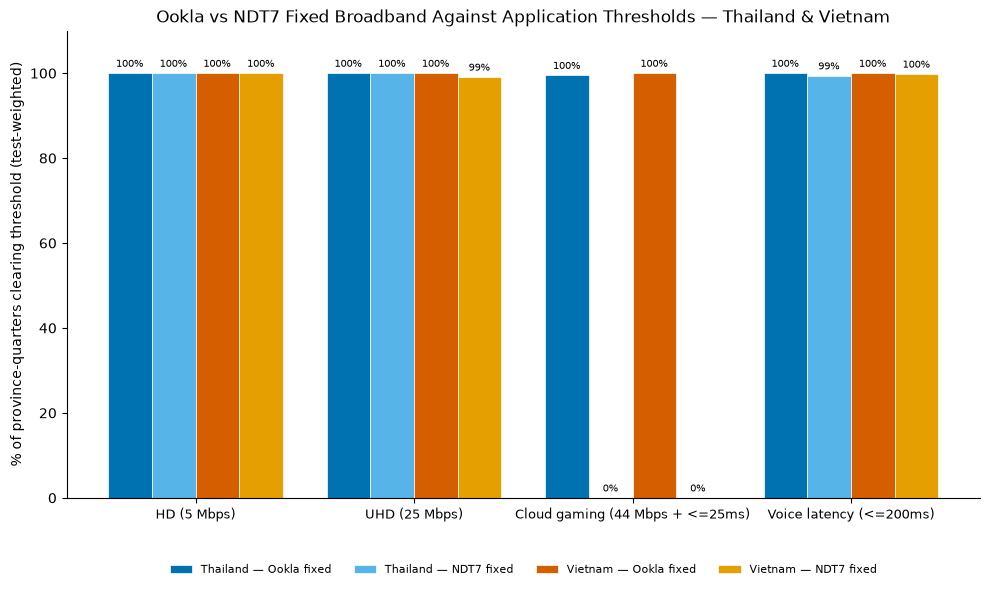

Mobile (NDT7 only, no Ookla-mobile reload here): Thailand mobile n=81, Vietnam mobile n=4 (too thin, excluded from narrative) --


,HD (5 Mbps),UHD (25 Mbps),Cloud gaming (44 Mbps + <=25ms),Voice latency (<=200ms),n_province_quarters,n_tests_total
segment,,,,,,
Thailand — NDT7 mobile,100.0,66.9,0.0,100.0,81,16434567
Vietnam — NDT7 mobile,100.0,92.8,0.0,100.0,4,59784


In [5]:
metrics = list(THRESH.keys())
segs = ['Thailand — Ookla fixed', 'Thailand — NDT7 fixed', 'Vietnam — Ookla fixed', 'Vietnam — NDT7 fixed']
colors = {'Thailand — Ookla fixed': '#0072B2', 'Thailand — NDT7 fixed': '#56B4E9',
          'Vietnam — Ookla fixed':  '#D55E00', 'Vietnam — NDT7 fixed':  '#E69F00'}

x = np.arange(len(metrics))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 6))
for i, seg in enumerate(segs):
    vals = compare_pct.loc[seg, metrics].values.astype(float)
    bars = ax.bar(x + i * width, vals, width, label=seg, color=colors[seg], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f'{val:.0f}%', ha='center', fontsize=7.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=9)
ax.set_ylabel('% of province-quarters clearing threshold (test-weighted)')
ax.set_ylim(0, 110)
ax.set_title('Ookla vs NDT7 Fixed Broadband Against Application Thresholds — Thailand & Vietnam')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Mobile (NDT7 only, no Ookla-mobile reload here): Thailand mobile n=81, Vietnam mobile n=4 (too thin, excluded from narrative) --')
compare_pct.loc[['Thailand — NDT7 mobile', 'Vietnam — NDT7 mobile']]

### The cloud-gaming-latency floor: 0% everywhere in NDT7

Every single NDT7 province-quarter — Thailand and Vietnam, fixed **and** mobile, all 812 rows —
has `avg_lat_ms_wt` above 25 ms (minimum observed: 34.2ms Thailand fixed, 40.1ms Thailand mobile,
44.9ms Vietnam fixed, 99.8ms Vietnam mobile). This is not a province-specific problem the way
Ookla's Mae Hong Son outlier was, and it is not a Thailand-specific artifact either — it holds
identically in a second, independent country — which points to a structural cause rather than
a last-mile quality issue in either country:

- M-Lab (unlike Ookla) does not let ISPs host measurement servers inside their own network — per
  Lübben & Misfeld, Germany's *entire* national M-Lab footprint is 2 physical locations (Frankfurt,
  Hamburg). M-Lab very likely has **no server physically inside Thailand or Vietnam**, so NDT7's
  measured RTT bakes in real propagation distance to the nearest M-Lab site (plausibly
  Singapore/Hong Kong/Japan) on top of last-mile latency — Ookla, by contrast, can measure against
  an in-country, ISP-hosted server. Vietnam's higher floor than Thailand's (44.9ms vs 34.2ms fixed)
  is consistent with a different/farther nearest-POP distance per country, which would be a further
  point in favor of the infrastructure-footprint explanation over a national-network-quality one.
- **Not verified in this notebook** — would need M-Lab's public site list for Asia to confirm which
  POP Thai/Vietnamese NDT7 tests actually hit. Flag as the concrete next check, not an assumed fact.
- Practical implication for the paper: **NDT7's cloud-gaming-latency numbers should not be read as
  "Thailand/Vietnam fail the 25ms bar"** the way the Ookla Mae Hong Son finding was — that's likely
  an artifact of NDT7's own infrastructure footprint, not evidence about either country's networks.
  Contrast with Ookla, where the same threshold *did* show real geographic signal (Mae Hong Son /
  Nan in Thailand; see the all-8-country breakdown in `rq1_thresholds_ookla.ipynb` for more).

### Mobile province-level detail — Thailand only

Vietnam mobile (n=4 province-quarters) is too thin for any province-level breakdown — this
section is Thailand-only because that's the only country with a usable NDT7 mobile sample, not
because Thailand was chosen as the focus.

In [6]:
mobile_th = all_df[all_df['segment'] == 'Thailand — NDT7 mobile']

prov_mobile = (
    mobile_th.groupby('province')
    .apply(lambda d: pd.Series({
        'UHD (25 Mbps)': weighted_pass_rate(d, 'UHD (25 Mbps)') * 100,
        'Cloud gaming speed+latency (44 Mbps + <=25ms)': weighted_pass_rate(d, 'Cloud gaming (44 Mbps + <=25ms)') * 100,
        'total_tests': d['total_tests'].sum(),
    }), include_groups=False)
    .sort_values('total_tests', ascending=False)
)
prov_mobile.round(1).head(15)

,UHD (25 Mbps),Cloud gaming speed+latency (44 Mbps + <=25ms),total_tests
province,,,
Bangkok Metropolis,66.2,0.0,15391599.0
Nonthaburi,67.0,0.0,338274.0
Chiang Mai,100.0,0.0,277213.0
Samut Prakan,64.9,0.0,213098.0
Chon Buri,100.0,0.0,79732.0
Surat Thani,100.0,0.0,32115.0
Pathum Thani,55.6,0.0,19727.0
Phuket,0.0,0.0,18102.0
Songkhla,39.0,0.0,14512.0


**Not a low-sample noise artifact, and not a rural-vs-urban story either.** Ranking by test
volume: Bangkok Metropolis (15.4M tests, 12 quarters) clears UHD only **66%**; Nonthaburi (338k,
7Q) **67%**; Samut Prakan (213k, 7Q) **65%**; Pathum Thani (20k, 4Q) **56%** — the entire Bangkok
metro cluster underperforms, each on a solid multi-quarter sample, not a fluke. Meanwhile
**Chiang Mai (277k tests, 9Q) and Chon Buri (80k, 6Q) — comparably large samples — sit at 100%**,
same as smaller-but-still-multi-quarter Nakhon Ratchasima, Rayong, Khon Kaen, Surat Thani. So this
isn't "small province, unreliable data" — it's specifically the **capital region** that
underperforms on mobile UHD while major secondary cities elsewhere do not. Phuket (18k tests, only
1 quarter — flag as thin) and Songkhla (14.5k, 3Q) also fail badly, plausibly a tourist-load /
coastal-capacity story worth checking separately. The likely read: **mobile network congestion
concentrated in the highest-density metro area**, not an infrastructure gap in remote provinces —
the opposite of the usual "rural underserved" framing.

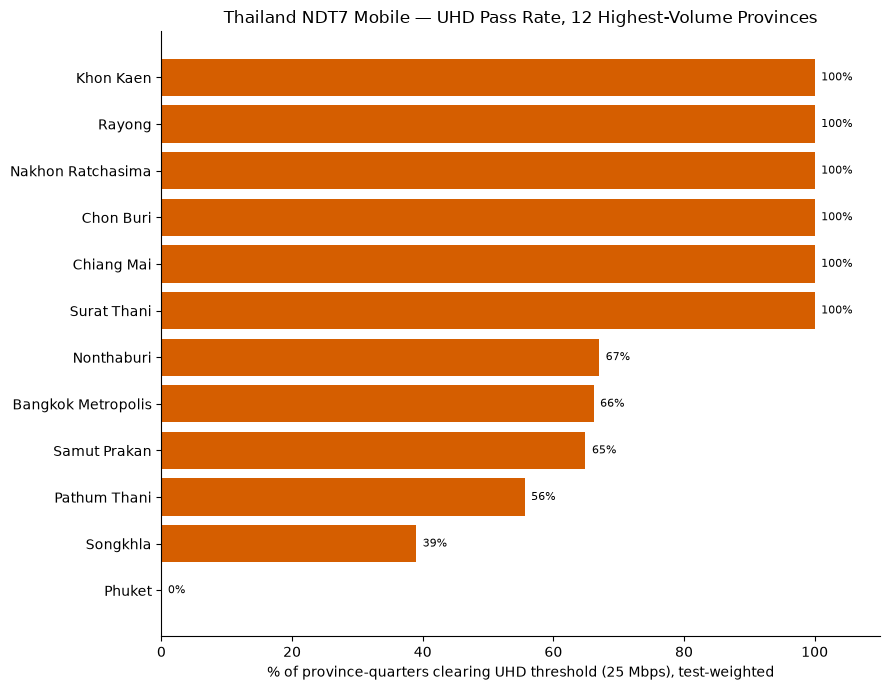

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
top_by_volume = prov_mobile.head(12).sort_values('UHD (25 Mbps)')
bars = ax.barh(top_by_volume.index, top_by_volume['UHD (25 Mbps)'], color='#D55E00', edgecolor='none')
for bar, val in zip(bars, top_by_volume['UHD (25 Mbps)']):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f'{val:.0f}%', va='center', fontsize=8)
ax.set_xlabel('% of province-quarters clearing UHD threshold (25 Mbps), test-weighted')
ax.set_title('Thailand NDT7 Mobile — UHD Pass Rate, 12 Highest-Volume Provinces')
ax.set_xlim(0, 110)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Key Findings (RQ1, NDT7)

- **NDT7 fixed broadband looks almost as uniformly "good" as Ookla fixed, in both countries** —
  HD 100% and UHD 99-100% across all 517 Thailand and 210 Vietnam province-quarters (Vietnam UHD
  99.1%, essentially no speed-threshold variance either country), matching the Ookla fixed result
  for both. Cloud-gaming *speed* alone is near-universal pass in both too.
- **NDT7 mobile is where the ETDA-complaint side of RQ1 finally becomes visible in the data —
  and it's a capital-region story, not a rural one.** (Thailand only: Vietnam mobile's n=4 is too
  thin for this breakdown.) Bangkok Metropolis, Nonthaburi, Samut Prakan, and Pathum Thani (the
  whole Bangkok metro cluster, each on a solid multi-quarter sample) clear UHD only 55-67% of the
  time, while comparably large, multi-quarter samples in Chiang Mai and Chon Buri sit at 100%.
  This is real and reproducible, not small-sample noise — and it inverts the usual "rural
  underserved" framing: the highest-density metro area is where mobile degrades, plausibly a
  congestion story. Phuket and Songkhla also fail badly (tourist-load / coastal-capacity, worth
  checking separately). This is the first result across both Ookla and NDT7 that plausibly
  supports the "internet feels bad" side of the RQ1 tension.
- **Every NDT7 measurement — fixed and mobile, Thailand and Vietnam alike, all 812 rows — fails
  the 25ms cloud-gaming latency bar**, with a floor that differs by country (34-40ms Thailand,
  45-100ms Vietnam) but never clears 25ms in either. Holding in a second, independent country
  strengthens the read that this is an NDT7 infrastructure artifact (no in-country M-Lab server,
  unlike Ookla's ISP-hosted servers) rather than a real network-quality problem in either country —
  **do not present this as "Thailand/Vietnam fail gaming latency"** without first checking M-Lab's
  actual Asia server locations (not done here).
- **Direct implication for the paper's RQ1 answer:** fixed broadband is genuinely good by these
  thresholds on both tools, in both countries with NDT7 data. Mobile broadband is where the two
  datasets actually disagree with the Ookla story and start explaining the complaint-survey side —
  **this is the strongest lead so far for resolving the Ookla-vs-ETDA tension**, and argues for
  extending this same province-level-mobile analysis before writing the paper's Results section
  (contingent on more NDT7 mobile data becoming available for Vietnam or other countries).
- **Cambodia excluded entirely** — 0 reliable NDT7 province-quarters in either fixed or mobile
  after the reliability filter. Vietnam mobile (n=4) kept in tables for completeness but is too
  thin to use in the narrative. Philippines/Singapore/Laos/Malaysia/Myanmar have no NDT7
  collection in scope at all — this notebook's 2-country limit is a data-availability constraint,
  not a deliberate Thailand-centric scope choice (see cell 1 scope note).
- **Not yet done:** per-test/percentile-level analysis (this is still province-quarter-average,
  same limitation as the Ookla notebook) — the natural next step given how much signal the mobile
  breakdown already surfaced at this coarse level.